In [1]:
import numpy as np

def harmonic_avg(a, b):
    """Compute the harmonic mean of two values (interface permittivity)."""
    return (2 * a * b) / (a + b)

def compute_interface_permittivities(eps, i, j, k):
    """
    Compute the six interface-averaged permittivities for a given grid point (i, j, k).
    Uses harmonic averaging as defined in the equations.
    """
    eps_ip_jk = harmonic_avg(eps[i, j, k], eps[i+1, j, k])  # ε[i+1/2, j, k]
    eps_im_jk = harmonic_avg(eps[i, j, k], eps[i-1, j, k])  # ε[i-1/2, j, k]
    eps_i_jp_k = harmonic_avg(eps[i, j, k], eps[i, j+1, k]) # ε[i, j+1/2, k]
    eps_i_jm_k = harmonic_avg(eps[i, j, k], eps[i, j-1, k]) # ε[i, j-1/2, k]
    eps_ij_kp  = harmonic_avg(eps[i, j, k], eps[i, j, k+1]) # ε[i, j, k+1/2]
    eps_ij_km  = harmonic_avg(eps[i, j, k], eps[i, j, k-1]) # ε[i, j, k-1/2]

    return eps_ip_jk, eps_im_jk, eps_i_jp_k, eps_i_jm_k, eps_ij_kp, eps_ij_km

def update_phi(phi, eps, i, j, k):
    """
    Update phi[i, j, k] using the 3D finite difference stencil
    with harmonically averaged interface permittivities.
    """
    e_ip, e_im, e_jp, e_jm, e_kp, e_km = compute_interface_permittivities(eps, i, j, k)

    numerator = (
        e_ip * phi[i+1, j, k] +
        e_im * phi[i-1, j, k] +
        e_jp * phi[i, j+1, k] +
        e_jm * phi[i, j-1, k] +
        e_kp * phi[i, j, k+1] +
        e_km * phi[i, j, k-1]
    )

    denominator = e_ip + e_im + e_jp + e_jm + e_kp + e_km

    return numerator / denominator

def solve(phi, eps, max_iter=1000, tol=1e-6):
    """
    Iteratively solve for phi over the interior grid points
    using Gauss-Seidel relaxation.
    
    Args:
        phi  : 3D array of potential values (boundary conditions pre-set)
        eps  : 3D array of permittivity values
        max_iter : maximum number of iterations
        tol  : convergence tolerance
    
    Returns:
        phi  : converged potential field
    """
    Nx, Ny, Nz = phi.shape

    for iteration in range(max_iter):
        max_diff = 0.0

        # Iterate over interior points only (boundaries are fixed)
        for i in range(1, Nx - 1):
            for j in range(1, Ny - 1):
                for k in range(1, Nz - 1):
                    phi_new = update_phi(phi, eps, i, j, k)
                    max_diff = max(max_diff, abs(phi_new - phi[i, j, k]))
                    phi[i, j, k] = phi_new

        if max_diff < tol:
            print(f"Converged after {iteration + 1} iterations.")
            break
    else:
        print(f"Did not converge within {max_iter} iterations.")

    return phi


# --- Example usage ---
if __name__ == "__main__":
    Nx, Ny, Nz = 20, 20, 20

    phi = np.zeros((Nx, Ny, Nz))
    eps = np.ones((Nx, Ny, Nz))

    # Example: two-region permittivity
    eps[:, :, Nz//2:] = 2.0

    # Example boundary conditions
    phi[0, :, :]  = 1.0   # left face
    phi[-1, :, :] = 0.0   # right face

    phi = solve(phi, eps, max_iter=2000, tol=1e-7)
    print("Solution complete. phi shape:", phi.shape)

Converged after 414 iterations.
Solution complete. phi shape: (20, 20, 20)


In [2]:
phi

array([[[1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
         1.00000000e+00, 1.00000000e+00, 1.00000000e+00],
        [1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
         1.00000000e+00, 1.00000000e+00, 1.00000000e+00],
        [1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
         1.00000000e+00, 1.00000000e+00, 1.00000000e+00],
        ...,
        [1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
         1.00000000e+00, 1.00000000e+00, 1.00000000e+00],
        [1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
         1.00000000e+00, 1.00000000e+00, 1.00000000e+00],
        [1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
         1.00000000e+00, 1.00000000e+00, 1.00000000e+00]],

       [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 3.33082340e-01, 4.30793420e-01, ...,
         4.30793428e-01, 3.33082345e-01, 0.00000000e+00],
        [0.00000000e+00, 

In [2]:
import torch
import numpy
import matplotlib.pyplot as plt

In [6]:
def fill_area(arr,barr,val):
    for b in barr:
        arr[b[0],b[1][0]:b[1][1]+1]=val
        
def form_quarter_boundary(indx,x0,y0):
    dx = indx[0][0]-x0 # x index from center
    dy = indx[0][1]-y0   # y index from center
    barr = []
    if dx>=0 and dy>0:
        for idx in indx:
            yarr = (y0,idx[1])
            xarr = (idx[0],yarr)
            barr.append(xarr)
    if dx>=0 and dy<0:
        for idx in indx:
            yarr = (idx[1],y0)
            xarr = (idx[0],yarr)
            barr.append(xarr)
    if dx<0 and dy>=0:
        for idx in indx:
            yarr = (y0,idx[1])
            xarr = (idx[0],yarr)
            barr.append(xarr)
    if dx<0 and dy<=0:
        for idx in indx:
            yarr = (idx[1],y0)
            xarr = (idx[0],yarr)
            barr.append(xarr)
    return barr


    
def draw_plane(arr,z,val):
    """
    Fill 1 plane
    """
    arr[:,:,z]=val

def mirror_center(id_circ1,x0,y0):
    """
    mirror quarter-circle of the center point
    """
    id_circ2=[]
    for id in id_circ1:
        id_circ2.append((x0-(id[0]-x0),y0-(id[1]-y0)))
    return id_circ2

def mirror_xaxis(id_circ1,x0,y0,r):
    """
    mirror quarter-circle of Xaxis
    """
    id_circ2=[]
    for id in id_circ1:
        id_circ2.append((id[0],y0-(id[1]-y0)))
    return id_circ2

def mirror_yaxis(id_circ1,x0,y0,r):
    """
    mirror quarter-circle of Yaxis
    """
    id_circ2=[]
    for id in id_circ1:
        id_circ2.append((x0-(id[0]-x0),id[1]))
    return id_circ2

def draw_quarter(x0,y0,r):
    """
    Sorted by x-index IDs of an apper-right quarter-circle on a given grid
    x0,y0,r are in index units
    
    draws IV quadrant
    """
    x=0
    y=r
    d=3-2*r
    id_circ1=[]
    shifted=[]
    id_circ1.append((x,y))
    while x<=y :
        if d<0:
            d=d+4*x+6
            x=x+1
            id_circ1.append((x,y))
            id_circ1.append((y,x))
        if d>=0:
            d=d+4*(x-y)+6
            x=x+1
            y=y-1
            id_circ1.append((x,y))
            id_circ1.append((y,x))
    id_circ1.sort(key = lambda x: x[0])
    for id in id_circ1:
        sh=(id[0]+x0,id[1]+y0)
        shifted.append(sh)
    return shifted

In [43]:
epsilon = numpy.zeros((220, 220, 200))
pp_loweredge = 100
pcb_width = 16
pp_width = 1
n_pix = 5
LArpertimittivity = 1.5
FR4permittivity = 4.5
r1 = 19
shape = (int(len(epsilon)/n_pix),int(len(epsilon[0])/n_pix))

xc=int(shape[0]/2-1)
yc=int(shape[1]/2-1)
id_circ3 = draw_quarter(xc,yc,r1)
id_circ2 = mirror_xaxis(id_circ3,xc,yc,r1)
id_circ4 = mirror_yaxis(id_circ3,xc,yc,r1)
id_circ1 = mirror_center(id_circ3,xc,yc)
barr1=form_quarter_boundary(id_circ1,xc,yc)
barr2=form_quarter_boundary(id_circ2,xc,yc)
barr3=form_quarter_boundary(id_circ3,xc,yc)
barr4=form_quarter_boundary(id_circ4,xc,yc)
epsilon[:,:,pp_loweredge+pp_width+pcb_width+1:]=1.5
epsilon[:,:,pp_loweredge+pp_width:pp_loweredge+pp_width+pcb_width]=4.5
fill_area(epsilon[:,:,pp_loweredge+pp_width:pp_width+pp_width+pcb_width],barr1,LArpertimittivity)
fill_area(epsilon[:,:,pp_loweredge+pp_width:pp_width+pp_width+pcb_width],barr2,LArpertimittivity)
fill_area(epsilon[:,:,pp_loweredge+pp_width:pp_width+pp_width+pcb_width],barr3,LArpertimittivity)
fill_area(epsilon[:,:,pp_loweredge+pp_width:pp_width+pp_width+pcb_width],barr4,LArpertimittivity)
for i in range(n_pix):
    for j in range(n_pix):
        epsilon[i*shape[0]:(i+1)*shape[0],j*shape[1]:(j+1)*shape[1],pp_loweredge+pp_width:pp_width+pp_width+pcb_width]=epsilon[:shape[0],:shape[1],pp_loweredge+pp_width:pp_width+pp_width+pcb_width]

In [44]:
(epsilon == 4.5).sum()

np.int64(774400)

/tmp/ipykernel_2260064/4283803129.py:4: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, z, cmap='viridis', s=1, alpha=0.5, marker=',')


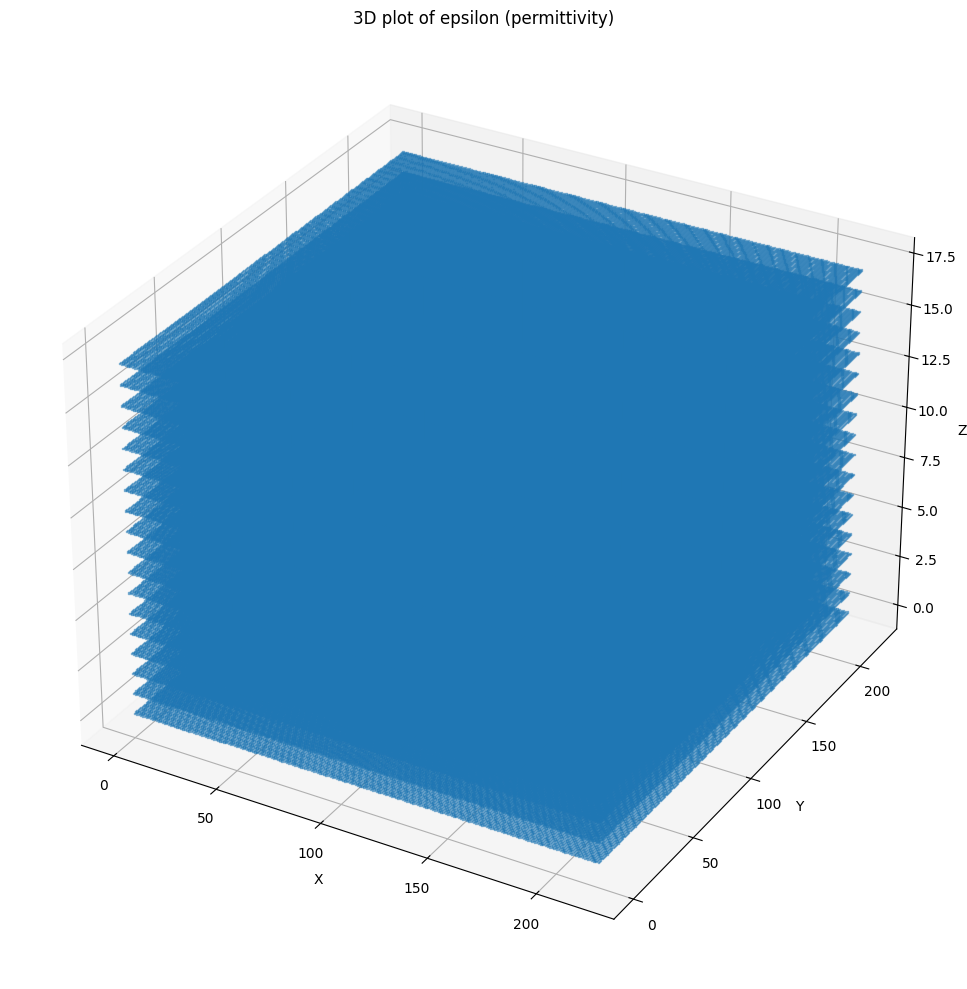

In [46]:
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
x, y, z = numpy.where(epsilon[:,:,pp_loweredge:150] != 1.5)
sc = ax.scatter(x, y, z, cmap='viridis', s=1, alpha=0.5, marker=',')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D plot of epsilon (permittivity)')
# ax.view_init(elev=90, azim=50)  # Adjust the elevation and azimuth for better visualization
plt.tight_layout()
# plt.savefig('store/epsilon_3d.png', dpi=150)
# plt.close()
plt.show()

In [37]:
(epsilon[:,:,:150] == 4.5).sum()

np.int64(774400)

In [47]:
epsilon = numpy.zeros((220, 220, 200))
pp_loweredge = 100
pcb_width = 16
pp_width = 1
n_pix = 5
LArpermittivity = 1.5
FR4permittivity = 4.5
r1 = 19
shape = (int(len(epsilon)/n_pix), int(len(epsilon[0])/n_pix))

xc = int(shape[0]/2 - 1)
yc = int(shape[1]/2 - 1)

# Draw circle boundary for one pixel tile
id_circ3 = draw_quarter(xc, yc, r1)
id_circ2 = mirror_xaxis(id_circ3, xc, yc, r1)
id_circ4 = mirror_yaxis(id_circ3, xc, yc, r1)
id_circ1 = mirror_center(id_circ3, xc, yc)
barr1 = form_quarter_boundary(id_circ1, xc, yc)
barr2 = form_quarter_boundary(id_circ2, xc, yc)
barr3 = form_quarter_boundary(id_circ3, xc, yc)
barr4 = form_quarter_boundary(id_circ4, xc, yc)

# z-ranges
z_lar_above  = pp_loweredge + pp_width + pcb_width + 1  # above shield
z_pcb_start  = pp_loweredge + pp_width                  # bottom of FR4+shield volume
z_pcb_end    = pp_loweredge + pp_width + pcb_width      # top of FR4+shield volume

# LAr above the shield grid
epsilon[:, :, z_lar_above:] = LArpermittivity

# Fill the entire FR4+shield volume with FR4 first
epsilon[:, :, z_pcb_start:z_pcb_end] = FR4permittivity

# Carve holes (LAr) in a single pixel tile using the circle boundary
tile = epsilon[:shape[0], :shape[1], z_pcb_start:z_pcb_end]
fill_area(tile, barr1, LArpermittivity)
fill_area(tile, barr2, LArpermittivity)
fill_area(tile, barr3, LArpermittivity)
fill_area(tile, barr4, LArpermittivity)

# Tile the single-pixel pattern across the full 5x5 grid
for i in range(n_pix):
    for j in range(n_pix):
        epsilon[i*shape[0]:(i+1)*shape[0], j*shape[1]:(j+1)*shape[1], z_pcb_start:z_pcb_end] = \
            epsilon[:shape[0], :shape[1], z_pcb_start:z_pcb_end]


/tmp/ipykernel_2260064/4283803129.py:4: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, z, cmap='viridis', s=1, alpha=0.5, marker=',')


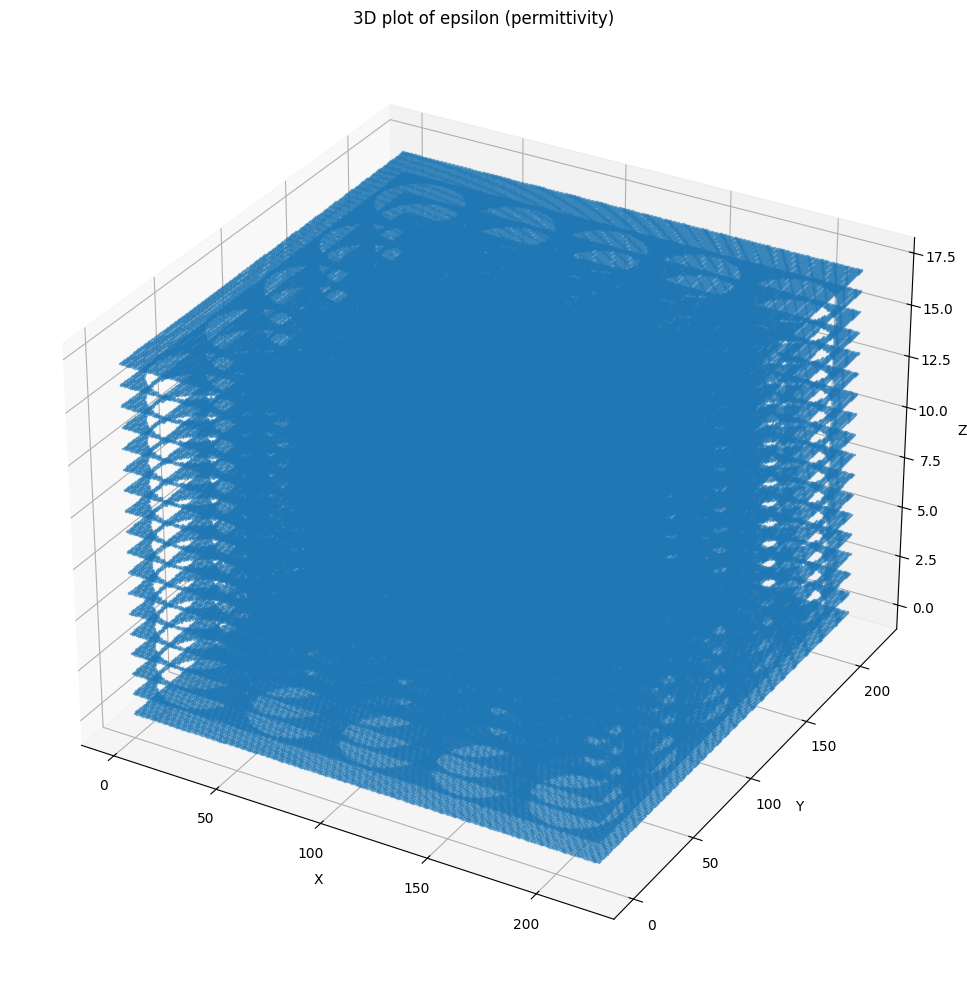

In [48]:
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
x, y, z = numpy.where(epsilon[:,:,pp_loweredge:150] != 1.5)
sc = ax.scatter(x, y, z, cmap='viridis', s=1, alpha=0.5, marker=',')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D plot of epsilon (permittivity)')
# ax.view_init(elev=90, azim=50)  # Adjust the elevation and azimuth for better visualization
plt.tight_layout()
# plt.savefig('store/epsilon_3d.png', dpi=150)
# plt.close()
plt.show()